# Hierarchical Orthogonality Test: Gemma vs Vault Gemma

## Hypothesis

**If differential privacy (Vault Gemma) preserves semantic hierarchy, then:**

The parent concept vector (e.g., "Animal") should be **orthogonal** to the difference vector between child and parent concepts (e.g., "Mammal" - "Animal").

### Mathematical Formulation:

For a hierarchical relationship: **Animal → Mammal**

- Let $\ell_{\text{animal}}$ = concept vector for "Animal"
- Let $\ell_{\text{mammal}}$ = concept vector for "Mammal"
- Let $d = \ell_{\text{mammal}} - \ell_{\text{animal}}$ = difference vector ("mammalness" independent of "animalness")

**Perfect orthogonality**: $\cos(\ell_{\text{animal}}, d) = 0$

---

## Test Procedure

1. **Compute concept vectors** using LDA for hierarchical concepts
2. **Measure orthogonality** between parent and difference vectors
3. **Compare Gemma vs Vault Gemma** across multiple hierarchies
4. **Visualize** the geometric relationships

In [1]:
!pip install -q transformers torch accelerate matplotlib numpy tqdm

In [2]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
import os
import json
import torch
import numpy as np
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
from sklearn.decomposition import PCA
import pandas as pd

PROJECT_ROOT = '/content/drive/MyDrive/690F Group 7/Final Research paper/Code'

if PROJECT_ROOT in sys.path:
    sys.path.remove(PROJECT_ROOT)

sys.path.insert(0, PROJECT_ROOT)

# 4. Test import
try:
    import hierarchical as hrc
    print("✓ Hierarchical package imported successfully!")
    print(f"Hierarchical module location: {hrc.__file__}")
except ImportError as e:
    print(f"Import failed: {e}")
    print(f"\nChecking contents of {PROJECT_ROOT}:")
    if os.path.exists(PROJECT_ROOT):
        print(os.listdir(PROJECT_ROOT))
        hierarchical_path = os.path.join(PROJECT_ROOT, 'hierarchical')
        if os.path.exists(hierarchical_path):
            print(f"\nContents of hierarchical folder:")
            print(os.listdir(hierarchical_path))

# 5. Set up paths for data and results
DATA_PATH = f'{PROJECT_ROOT}/data/'
RESULTS_DIR = f'{PROJECT_ROOT}/results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data: {DATA_PATH}")
print(f"Results: {RESULTS_DIR}")

✓ Hierarchical package imported successfully!
Hierarchical module location: /content/drive/MyDrive/690F Group 7/Final Research paper/Code/hierarchical/__init__.py
Project root: /content/drive/MyDrive/690F Group 7/Final Research paper/Code
Data: /content/drive/MyDrive/690F Group 7/Final Research paper/Code/data/
Results: /content/drive/MyDrive/690F Group 7/Final Research paper/Code/results/


In [4]:
# High-quality plot settings for poster
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

sns.set_palette("husl")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Configuration

In [5]:
# Model configurations
GEMMA_MODEL = "google/gemma-2b"
VAULT_GEMMA_MODEL = "google/vaultgemma-1b"

print(f"Gemma: {GEMMA_MODEL}")
print(f"Vault Gemma: {VAULT_GEMMA_MODEL}")

Gemma: google/gemma-2b
Vault Gemma: google/vaultgemma-1b


## Step 1: Load Models and Extract Representations

In [6]:
g_gemma, _, _ = hrc.get_g(GEMMA_MODEL, device)
vocab_dict_gemma, vocab_list_gemma = hrc.get_vocab(GEMMA_MODEL)
print(f"Gemma loaded: {g_gemma.shape}")

g_vault, _, _ = hrc.get_g(VAULT_GEMMA_MODEL, device)
vocab_dict_vault, vocab_list_vault = hrc.get_vocab(VAULT_GEMMA_MODEL)
print(f"Vault Gemma loaded: {g_vault.shape}")

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.95M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

Vault Gemma loaded: torch.Size([256000, 1152])


## Step 2: Define Hierarchical Concepts

We'll test the hierarchy: **Animal → {Mammal, Bird, Reptile, Fish}**

In [9]:
# Load animal hierarchies
with open(f'{DATA_PATH}/animals.json', 'r') as f:
    animals_data = json.load(f)

# Define hierarchy
HIERARCHY = {
    'Animal': {
        'children': ['mammal', 'bird', 'reptile', 'fish', 'amphibian', 'insect'],
        'words': []  # Will be union of all children
    }
}

# Add all child words to parent
for child in HIERARCHY['Animal']['children']:
    HIERARCHY['Animal']['words'].extend(animals_data[child])

print(f"Hierarchy defined:")
print(f"  Animal: {len(HIERARCHY['Animal']['words'])} total words")
for child in HIERARCHY['Animal']['children']:
    print(f"  - {child.capitalize()}: {len(animals_data[child])} words")

Hierarchy defined:
  Animal: 486 total words
  - Mammal: 169 words
  - Bird: 142 words
  - Reptile: 19 words
  - Fish: 100 words
  - Amphibian: 16 words
  - Insect: 40 words


## Step 3: Compute Concept Vectors Using LDA

In [10]:
def compute_concept_vectors(g, vocab_dict, hierarchy_data, animals_data):
    """
    Compute LDA-based concept vectors for all concepts in hierarchy.
    """
    concept_vectors = {}

    # Get animal category embeddings
    categories = list(animals_data.keys())
    animals_token, animals_ind, animals_g = hrc.get_animal_category(
        animals_data, categories, vocab_dict, g
    )

    # Compute parent concept (Animal)
    all_animal_tokens = []
    for cat in categories:
        all_animal_tokens.extend(animals_token[cat])
    all_animal_tokens = list(set(all_animal_tokens))

    print(f"Computing concept vector for Animal ({len(all_animal_tokens)} unique tokens)...")
    concept_vectors['Animal'] = hrc.estimate_cat_dir(all_animal_tokens, g, vocab_dict)

    # Compute child concepts
    for category in tqdm(categories, desc="Computing child concept vectors"):
        tokens = animals_token[category]
        if len(tokens) > 0:
            concept_vectors[category.capitalize()] = hrc.estimate_cat_dir(tokens, g, vocab_dict)

    return concept_vectors, animals_token

print("Computing concept vectors for Gemma...")
concepts_gemma, tokens_gemma = compute_concept_vectors(
    g_gemma, vocab_dict_gemma, HIERARCHY, animals_data
)

print("\nComputing concept vectors for Vault Gemma...")
concepts_vault, tokens_vault = compute_concept_vectors(
    g_vault, vocab_dict_vault, HIERARCHY, animals_data
)

print(f"Computed {len(concepts_gemma)} concept vectors for each model")

Computing concept vectors for Gemma...
Computing concept vector for Animal (487 unique tokens)...


Computing child concept vectors: 100%|██████████| 6/6 [00:06<00:00,  1.13s/it]



Computing concept vectors for Vault Gemma...
Computing concept vector for Animal (487 unique tokens)...


Computing child concept vectors: 100%|██████████| 6/6 [00:01<00:00,  4.44it/s]


✓ Computed 7 concept vectors for each model


## Step 4: Measure Hierarchical Orthogonality

In [11]:
def compute_orthogonality_metrics(concepts, parent_name='Animal'):
    """
    Compute orthogonality between parent and (child - parent) for all children.
    """
    results = []

    l_parent = concepts[parent_name]['lda']
    l_parent_norm = l_parent / l_parent.norm()

    for child_name, child_data in concepts.items():
        if child_name == parent_name:
            continue

        l_child = child_data['lda']
        l_child_norm = l_child / l_child.norm()

        # Compute difference vector
        d = l_child - l_parent
        d_norm = d / d.norm()

        # Compute angles
        cos_parent_diff = (l_parent_norm @ d_norm).item()
        angle_parent_diff = np.arccos(np.clip(cos_parent_diff, -1, 1)) * 180 / np.pi

        cos_parent_child = (l_parent_norm @ l_child_norm).item()
        angle_parent_child = np.arccos(np.clip(cos_parent_child, -1, 1)) * 180 / np.pi

        results.append({
            'child': child_name,
            'cos_parent_diff': cos_parent_diff,
            'angle_parent_diff': angle_parent_diff,
            'deviation_from_90': abs(90 - angle_parent_diff),
            'cos_parent_child': cos_parent_child,
            'angle_parent_child': angle_parent_child,
            'l_parent': l_parent_norm.cpu().numpy(),
            'l_child': l_child_norm.cpu().numpy(),
            'd': d_norm.cpu().numpy()
        })

    return results

ortho_gemma = compute_orthogonality_metrics(concepts_gemma)
ortho_vault = compute_orthogonality_metrics(concepts_vault)

# Create DataFrames for easy comparison
df_gemma = pd.DataFrame(ortho_gemma)
df_vault = pd.DataFrame(ortho_vault)

print("Orthogonality metrics computed")

Orthogonality metrics computed


## Step 5: Quantifiable Results

### 5.1 Summary Statistics

In [12]:
# Create comparison table
comparison = pd.DataFrame({
    'Concept': df_gemma['child'],
    'Gemma Angle (°)': df_gemma['angle_parent_diff'].round(2),
    'Vault Angle (°)': df_vault['angle_parent_diff'].round(2),
    'Gemma |cos|': np.abs(df_gemma['cos_parent_diff']).round(4),
    'Vault |cos|': np.abs(df_vault['cos_parent_diff']).round(4),
    'Gemma Deviation': df_gemma['deviation_from_90'].round(2),
    'Vault Deviation': df_vault['deviation_from_90'].round(2)
})

print("="*100)
print("HIERARCHICAL ORTHOGONALITY RESULTS: Animal → Children")
print("="*100)
print("\nAngle between parent and (child - parent):")
print("  - Perfect orthogonality = 90°")
print("  - Perfect alignment = 0° or 180°")
print("\n" + comparison.to_string(index=False))

# Summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)

avg_angle_gemma = df_gemma['angle_parent_diff'].mean()
avg_angle_vault = df_vault['angle_parent_diff'].mean()
avg_deviation_gemma = df_gemma['deviation_from_90'].mean()
avg_deviation_vault = df_vault['deviation_from_90'].mean()
avg_cos_gemma = np.abs(df_gemma['cos_parent_diff']).mean()
avg_cos_vault = np.abs(df_vault['cos_parent_diff']).mean()

print(f"\nGemma:")
print(f"  Average angle: {avg_angle_gemma:.2f}° (target: 90°)")
print(f"  Average deviation from 90°: {avg_deviation_gemma:.2f}°")
print(f"  Average |cos(parent, diff)|: {avg_cos_gemma:.4f} (target: 0)")

print(f"\nVault Gemma:")
print(f"  Average angle: {avg_angle_vault:.2f}° (target: 90°)")
print(f"  Average deviation from 90°: {avg_deviation_vault:.2f}°")
print(f"  Average |cos(parent, diff)|: {avg_cos_vault:.4f} (target: 0)")

print(f"\nComparison:")
if avg_deviation_vault < avg_deviation_gemma:
    improvement = ((avg_deviation_gemma - avg_deviation_vault) / avg_deviation_gemma) * 100
    print(f"  ✓ Vault Gemma is {improvement:.1f}% CLOSER to perfect orthogonality")
elif avg_deviation_vault > avg_deviation_gemma:
    degradation = ((avg_deviation_vault - avg_deviation_gemma) / avg_deviation_gemma) * 100
    print(f"  ✗ Vault Gemma is {degradation:.1f}% FURTHER from perfect orthogonality")
else:
    print(f"  ~ Both models have similar orthogonality")

print("\n" + "="*100)

HIERARCHICAL ORTHOGONALITY RESULTS: Animal → Children

Angle between parent and (child - parent):
  - Perfect orthogonality = 90°
  - Perfect alignment = 0° or 180°

  Concept  Gemma Angle (°)  Vault Angle (°)  Gemma |cos|  Vault |cos|  Gemma Deviation  Vault Deviation
   Mammal            90.48            87.48       0.0084       0.0439             0.48             2.52
     Bird            90.69            91.08       0.0120       0.0189             0.69             1.08
  Reptile            90.02            89.00       0.0004       0.0174             0.02             1.00
     Fish            92.05            98.23       0.0358       0.1432             2.05             8.23
Amphibian            90.63            95.38       0.0109       0.0938             0.63             5.38
   Insect            90.19            90.18       0.0033       0.0031             0.19             0.18

SUMMARY STATISTICS

Gemma:
  Average angle: 90.68° (target: 90°)
  Average deviation from 90°: 0.68°
  Av

## Visualization 1: Orthogonality Angle Comparison (Bar Chart)

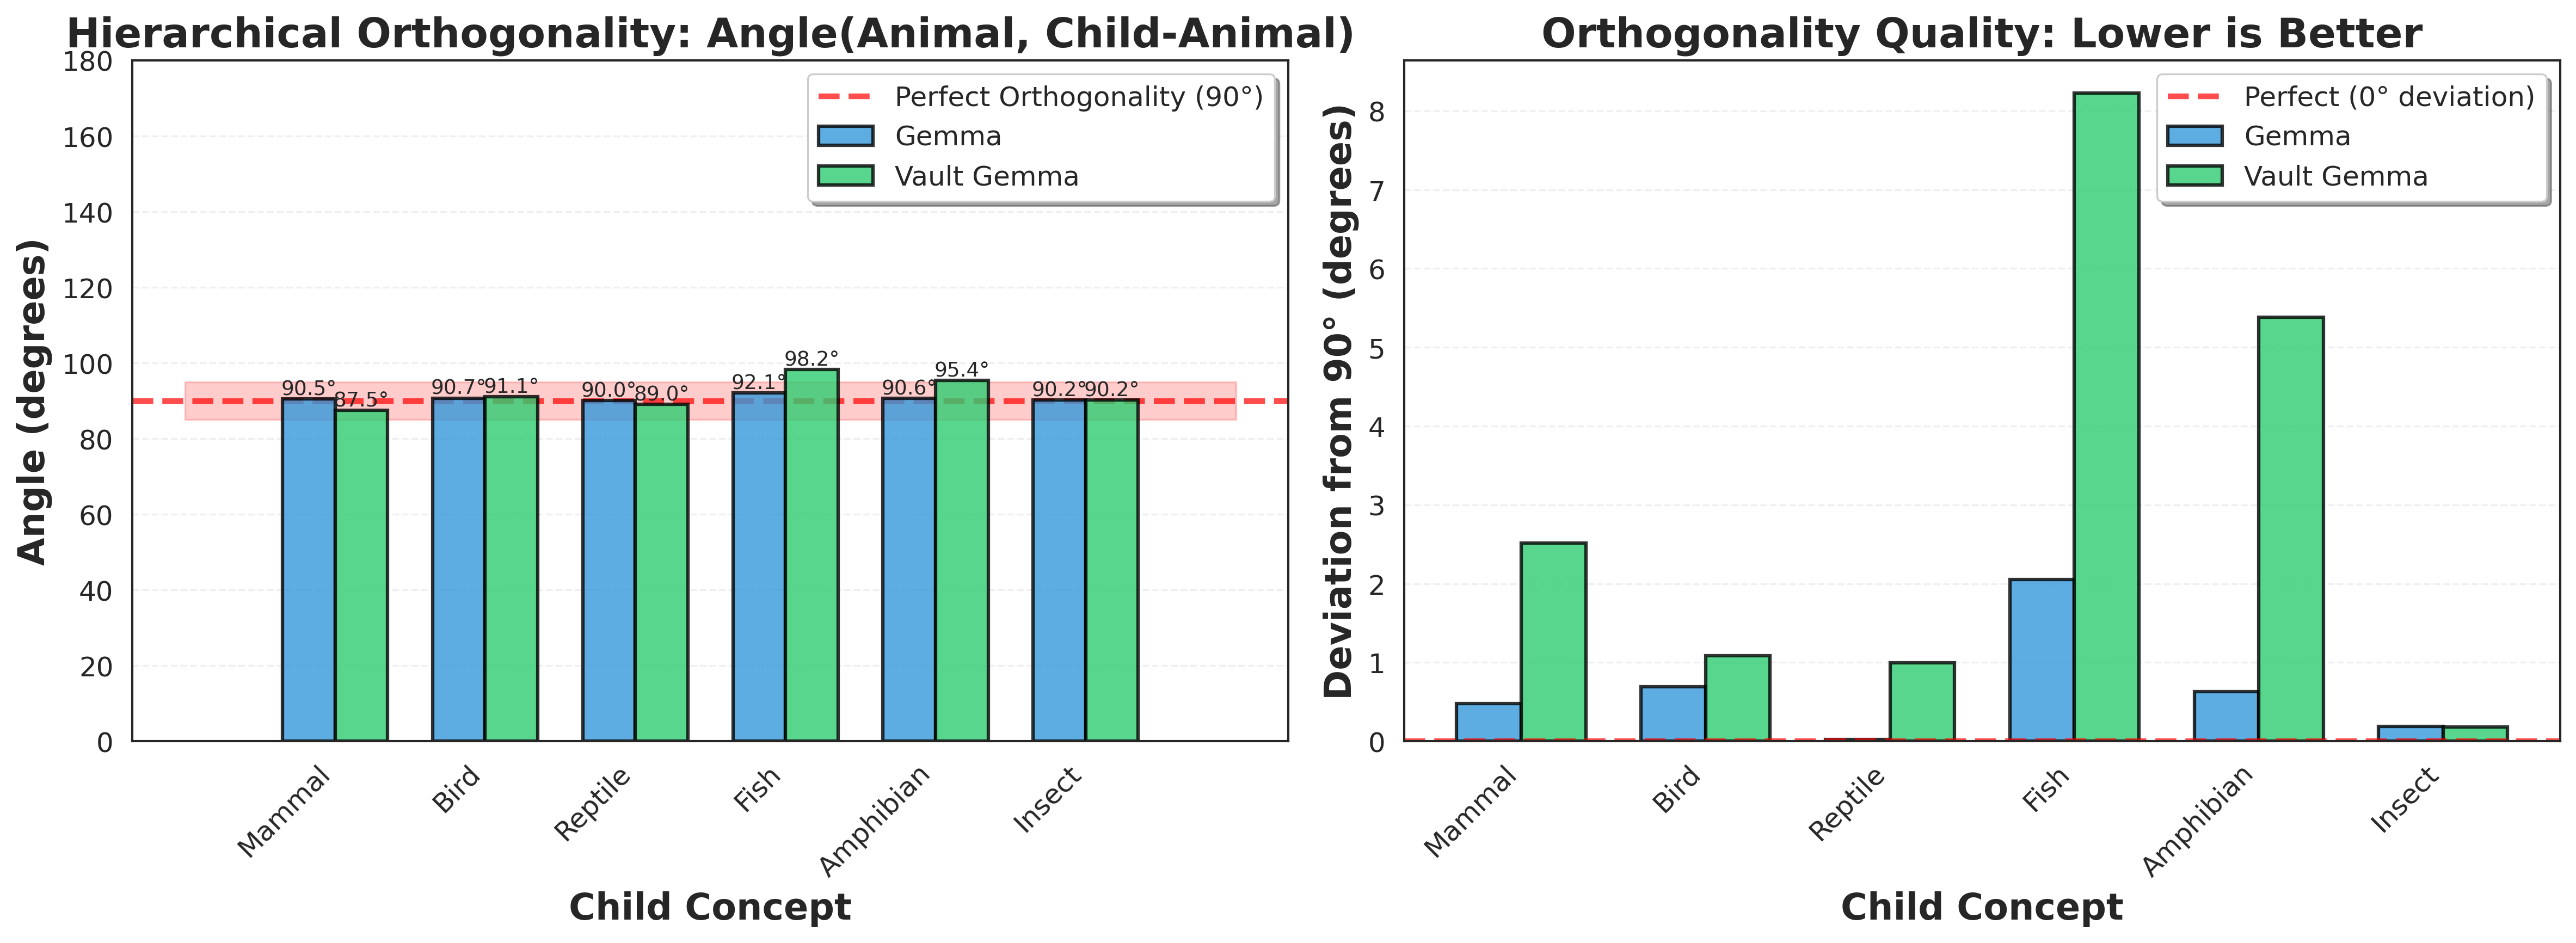

✓ Saved: orthogonality_angles_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

categories = df_gemma['child'].values
x = np.arange(len(categories))
width = 0.35

# Plot 1: Angles
bars1 = axes[0].bar(x - width/2, df_gemma['angle_parent_diff'], width,
                     label='Gemma', alpha=0.8, color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, df_vault['angle_parent_diff'], width,
                     label='Vault Gemma', alpha=0.8, color='#2ecc71', edgecolor='black', linewidth=1.5)

axes[0].axhline(y=90, color='red', linestyle='--', linewidth=2.5,
                label='Perfect Orthogonality (90°)', alpha=0.7, zorder=0)
axes[0].fill_between(range(-1, len(categories)+1), 85, 95, alpha=0.2, color='red', zorder=0)

axes[0].set_xlabel('Child Concept', fontweight='bold', fontsize=16)
axes[0].set_ylabel('Angle (degrees)', fontweight='bold', fontsize=16)
axes[0].set_title('Hierarchical Orthogonality: Angle(Animal, Child-Animal)',
                  fontweight='bold', fontsize=18)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=45, ha='right')
axes[0].legend(loc='upper right', frameon=True, shadow=True)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 180])

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}°', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}°', ha='center', va='bottom', fontsize=9)

# Plot 2: Deviation from 90°
bars3 = axes[1].bar(x - width/2, df_gemma['deviation_from_90'], width,
                     label='Gemma', alpha=0.8, color='#3498db', edgecolor='black', linewidth=1.5)
bars4 = axes[1].bar(x + width/2, df_vault['deviation_from_90'], width,
                     label='Vault Gemma', alpha=0.8, color='#2ecc71', edgecolor='black', linewidth=1.5)

axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2.5,
                label='Perfect (0° deviation)', alpha=0.7)

axes[1].set_xlabel('Child Concept', fontweight='bold', fontsize=16)
axes[1].set_ylabel('Deviation from 90° (degrees)', fontweight='bold', fontsize=16)
axes[1].set_title('Orthogonality Quality: Lower is Better',
                  fontweight='bold', fontsize=18)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=45, ha='right')
axes[1].legend(loc='upper right', frameon=True, shadow=True)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('orthogonality_angles_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: orthogonality_angles_comparison.png")

## Visualization 2: Cosine Similarity Heatmap

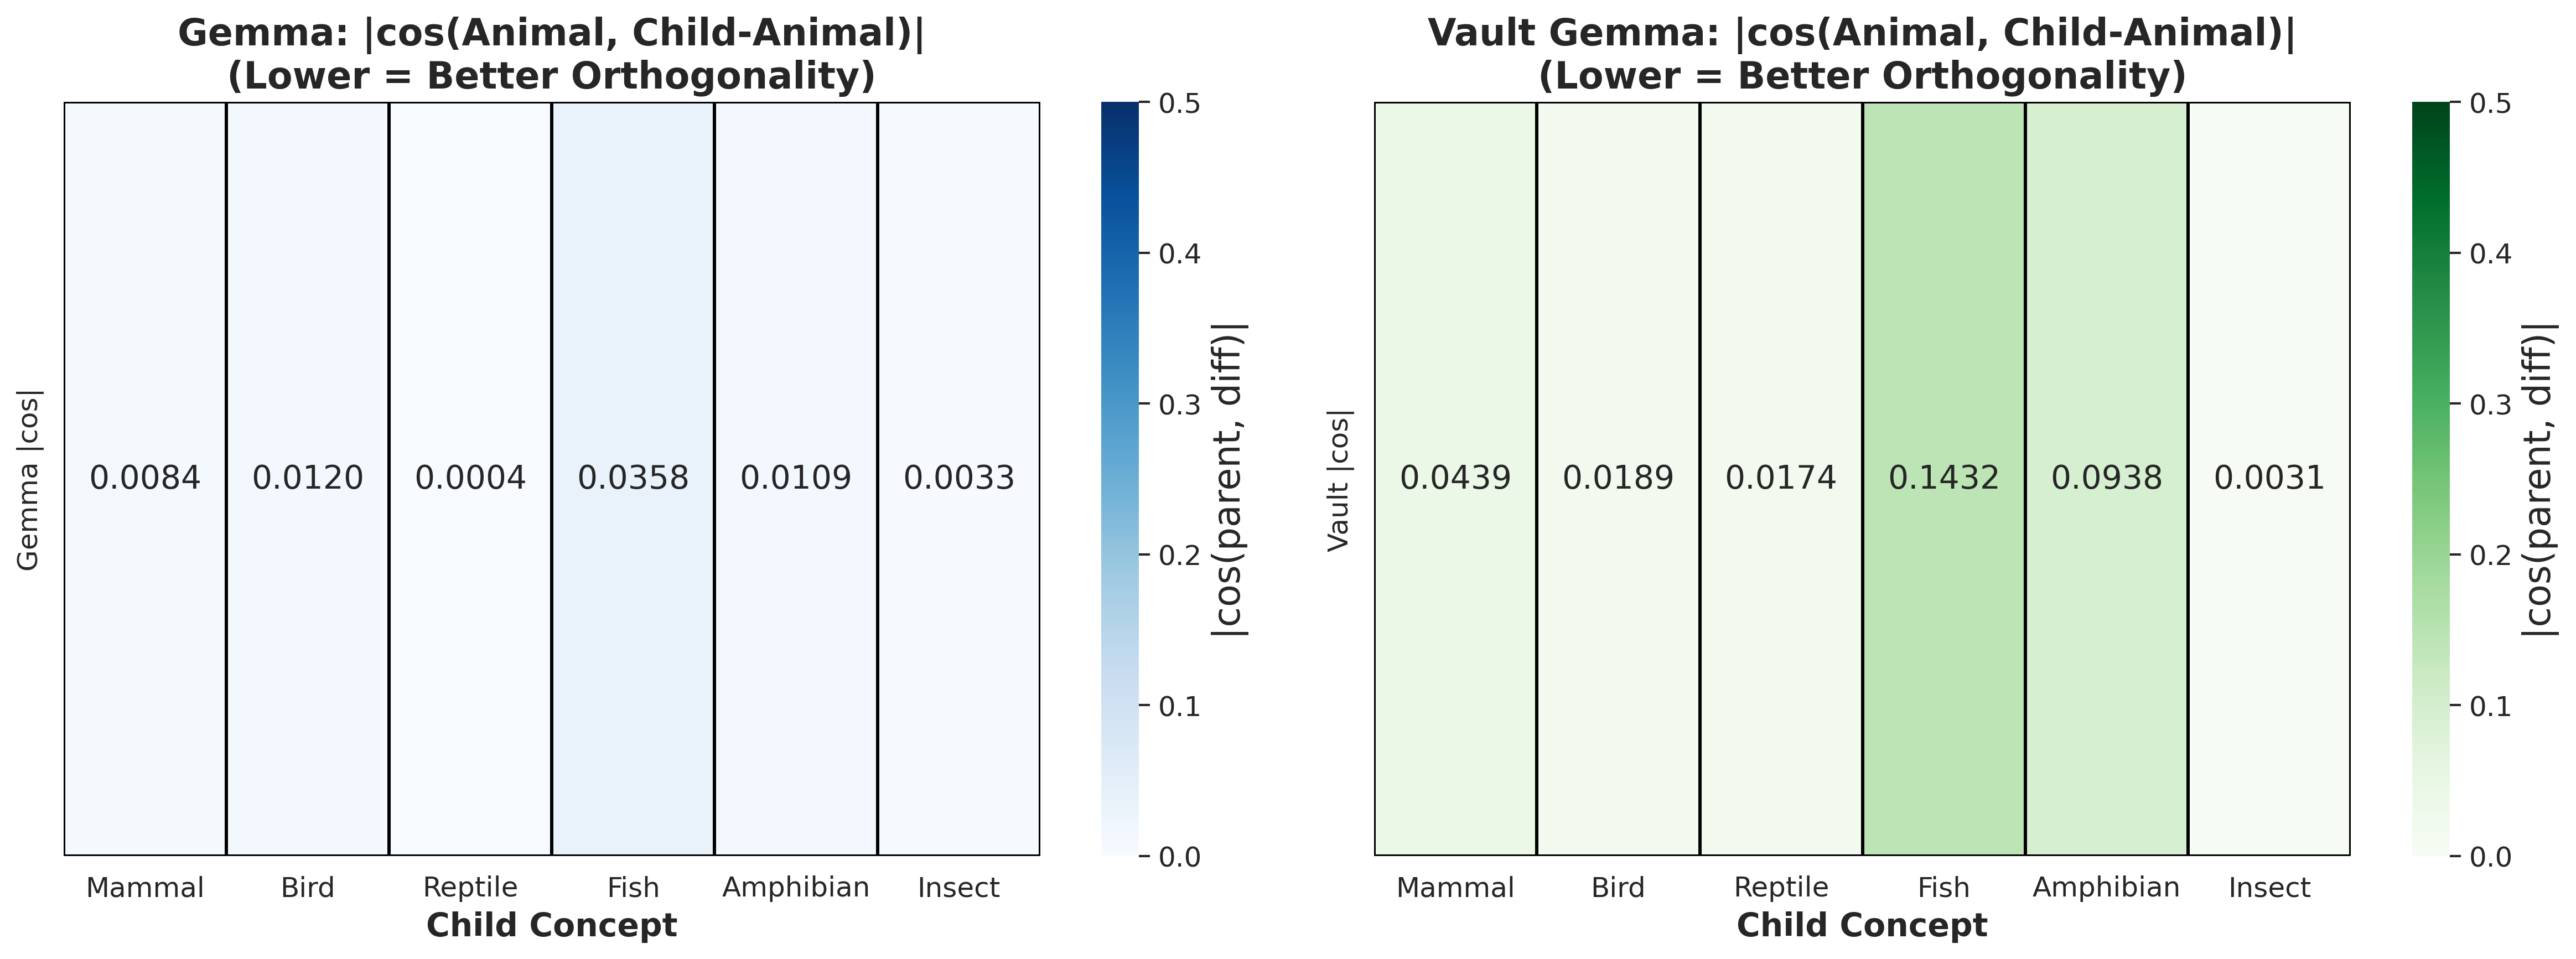

✓ Saved: orthogonality_heatmap.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for heatmap
data_gemma = comparison[['Concept', 'Gemma |cos|']].set_index('Concept').T
data_vault = comparison[['Concept', 'Vault |cos|']].set_index('Concept').T

# Plot heatmaps
sns.heatmap(data_gemma, annot=True, fmt='.4f', cmap='Blues', cbar_kws={'label': '|cos(parent, diff)|'},
            ax=axes[0], vmin=0, vmax=0.5, linewidths=1, linecolor='black')
axes[0].set_title('Gemma: |cos(Animal, Child-Animal)|\n(Lower = Better Orthogonality)',
                  fontweight='bold', fontsize=16)
axes[0].set_ylabel('')
axes[0].set_xlabel('Child Concept', fontweight='bold', fontsize=14)

sns.heatmap(data_vault, annot=True, fmt='.4f', cmap='Greens', cbar_kws={'label': '|cos(parent, diff)|'},
            ax=axes[1], vmin=0, vmax=0.5, linewidths=1, linecolor='black')
axes[1].set_title('Vault Gemma: |cos(Animal, Child-Animal)|\n(Lower = Better Orthogonality)',
                  fontweight='bold', fontsize=16)
axes[1].set_ylabel('')
axes[1].set_xlabel('Child Concept', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('orthogonality_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: orthogonality_heatmap.png")

## Visualization 3: 2D Projection of Concept Vectors

/tmp/ipython-input-1797300117.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(color_scheme)


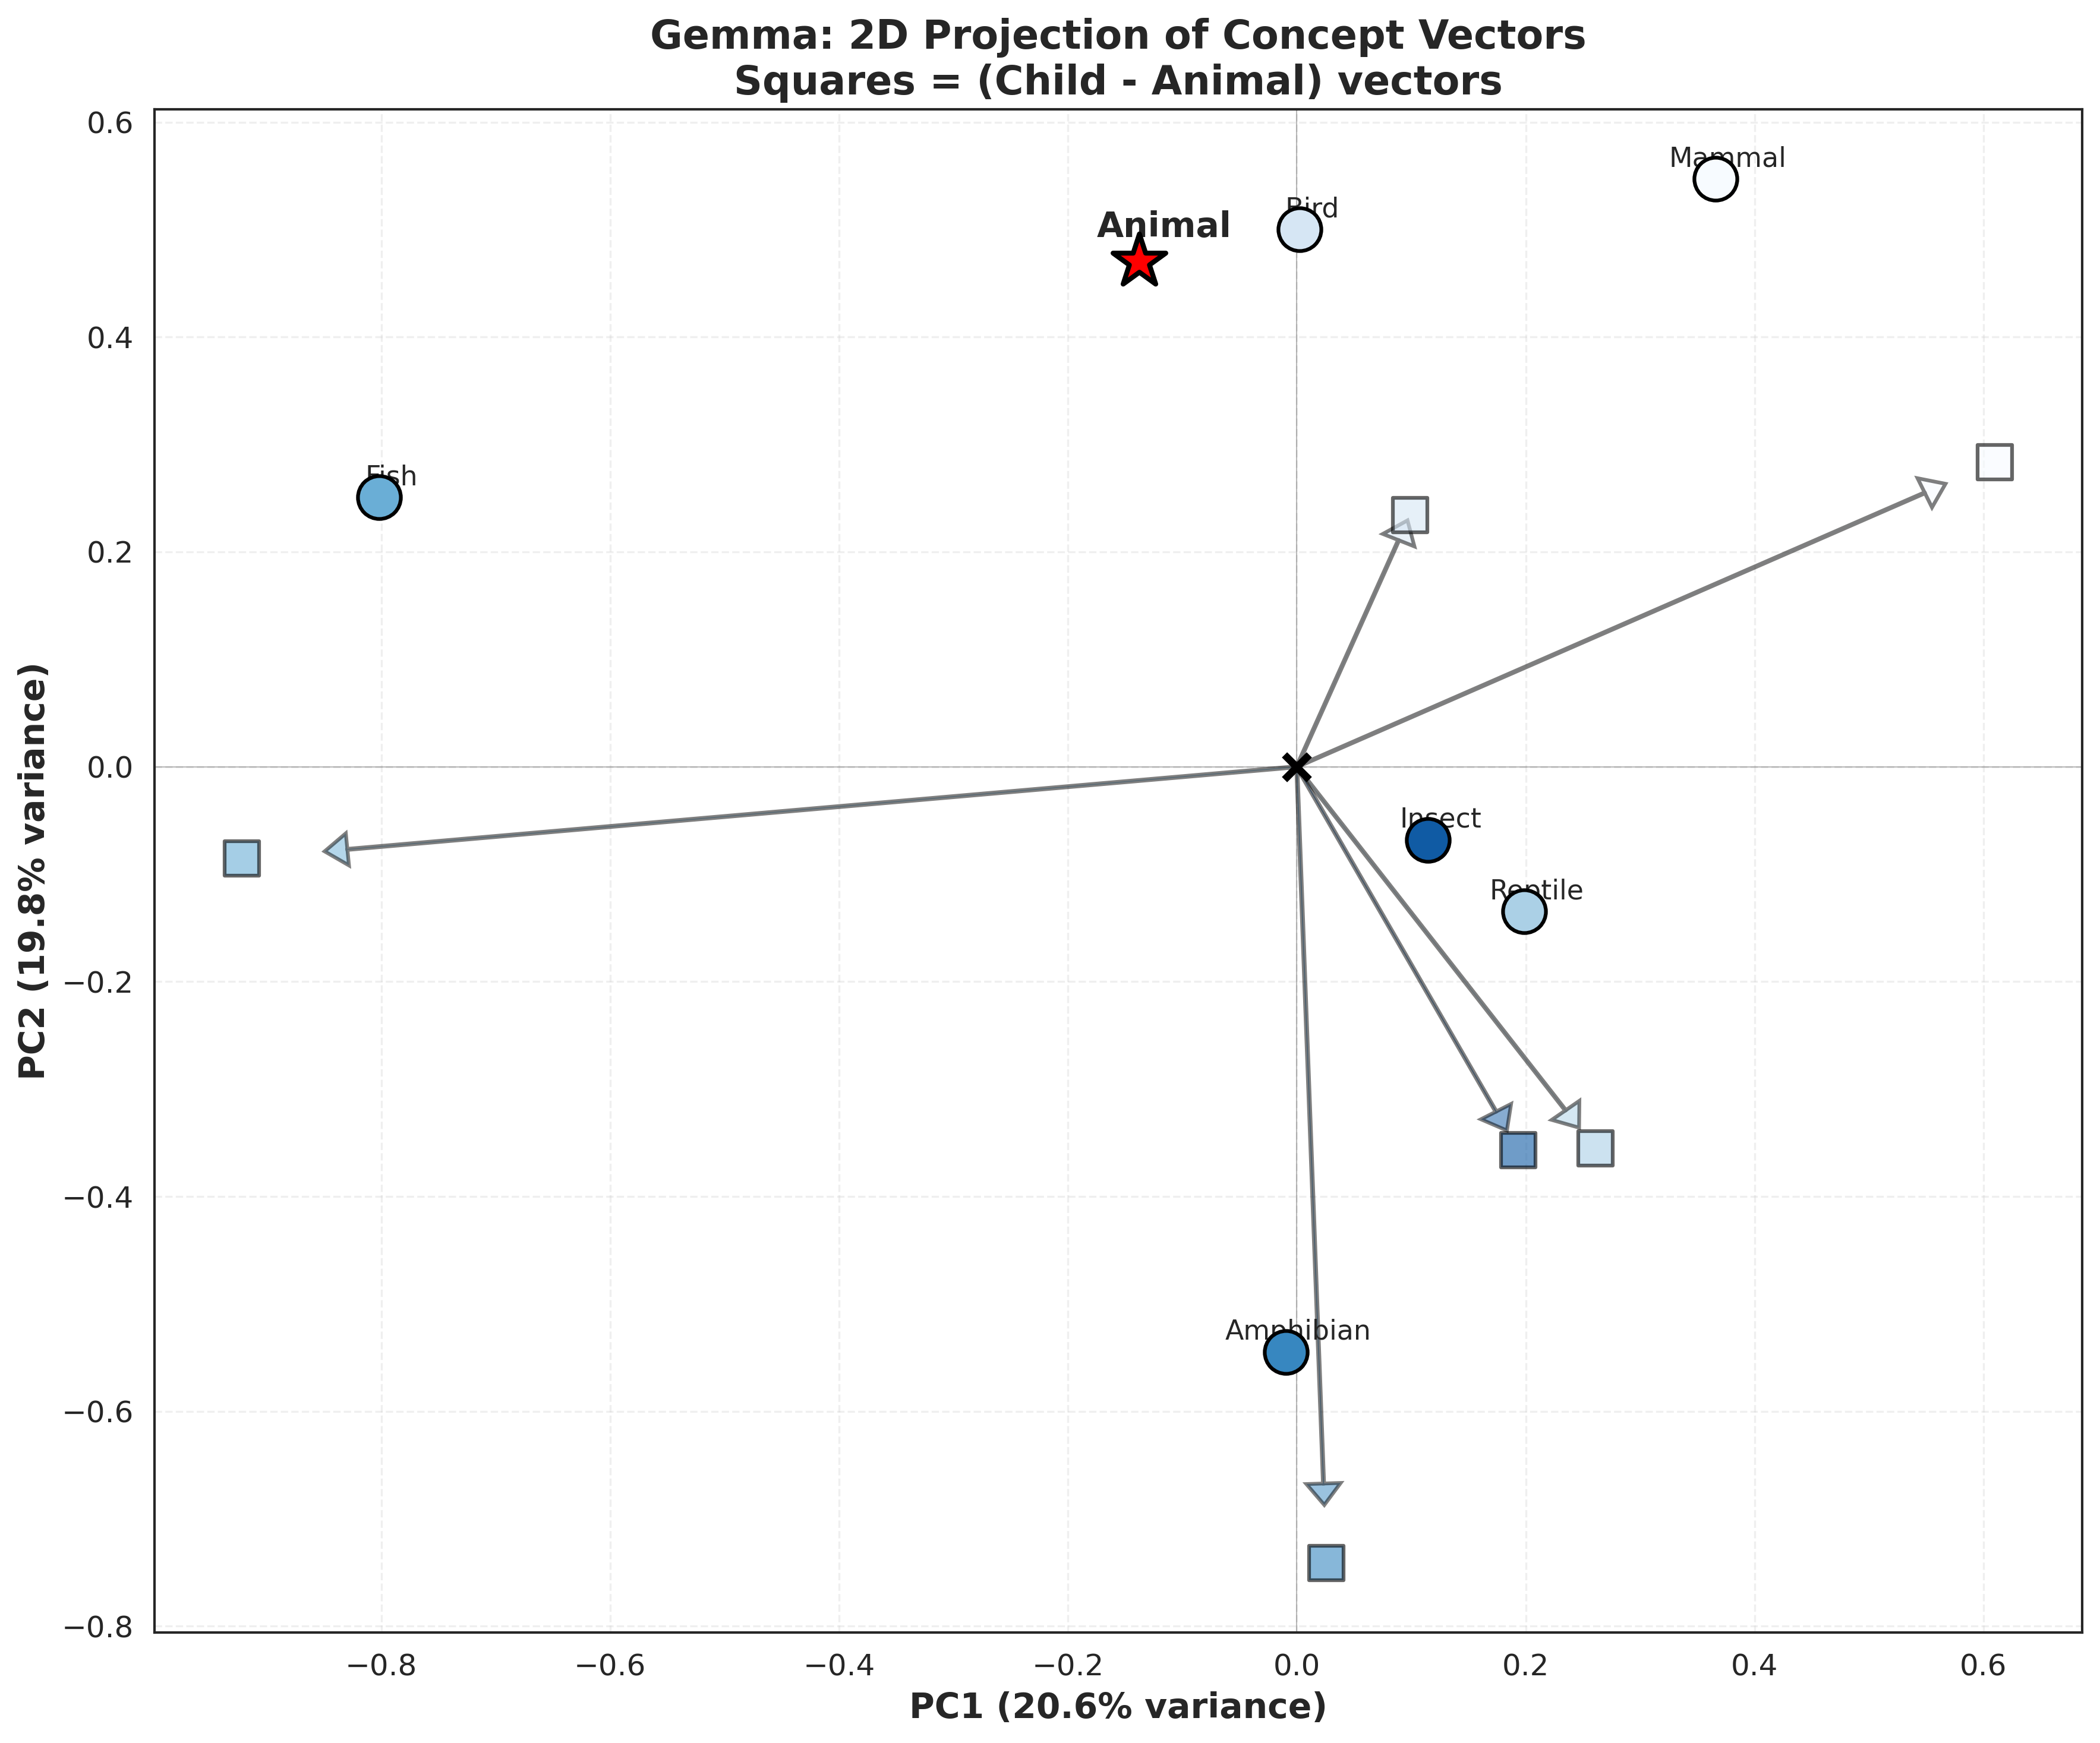

/tmp/ipython-input-1797300117.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(color_scheme)


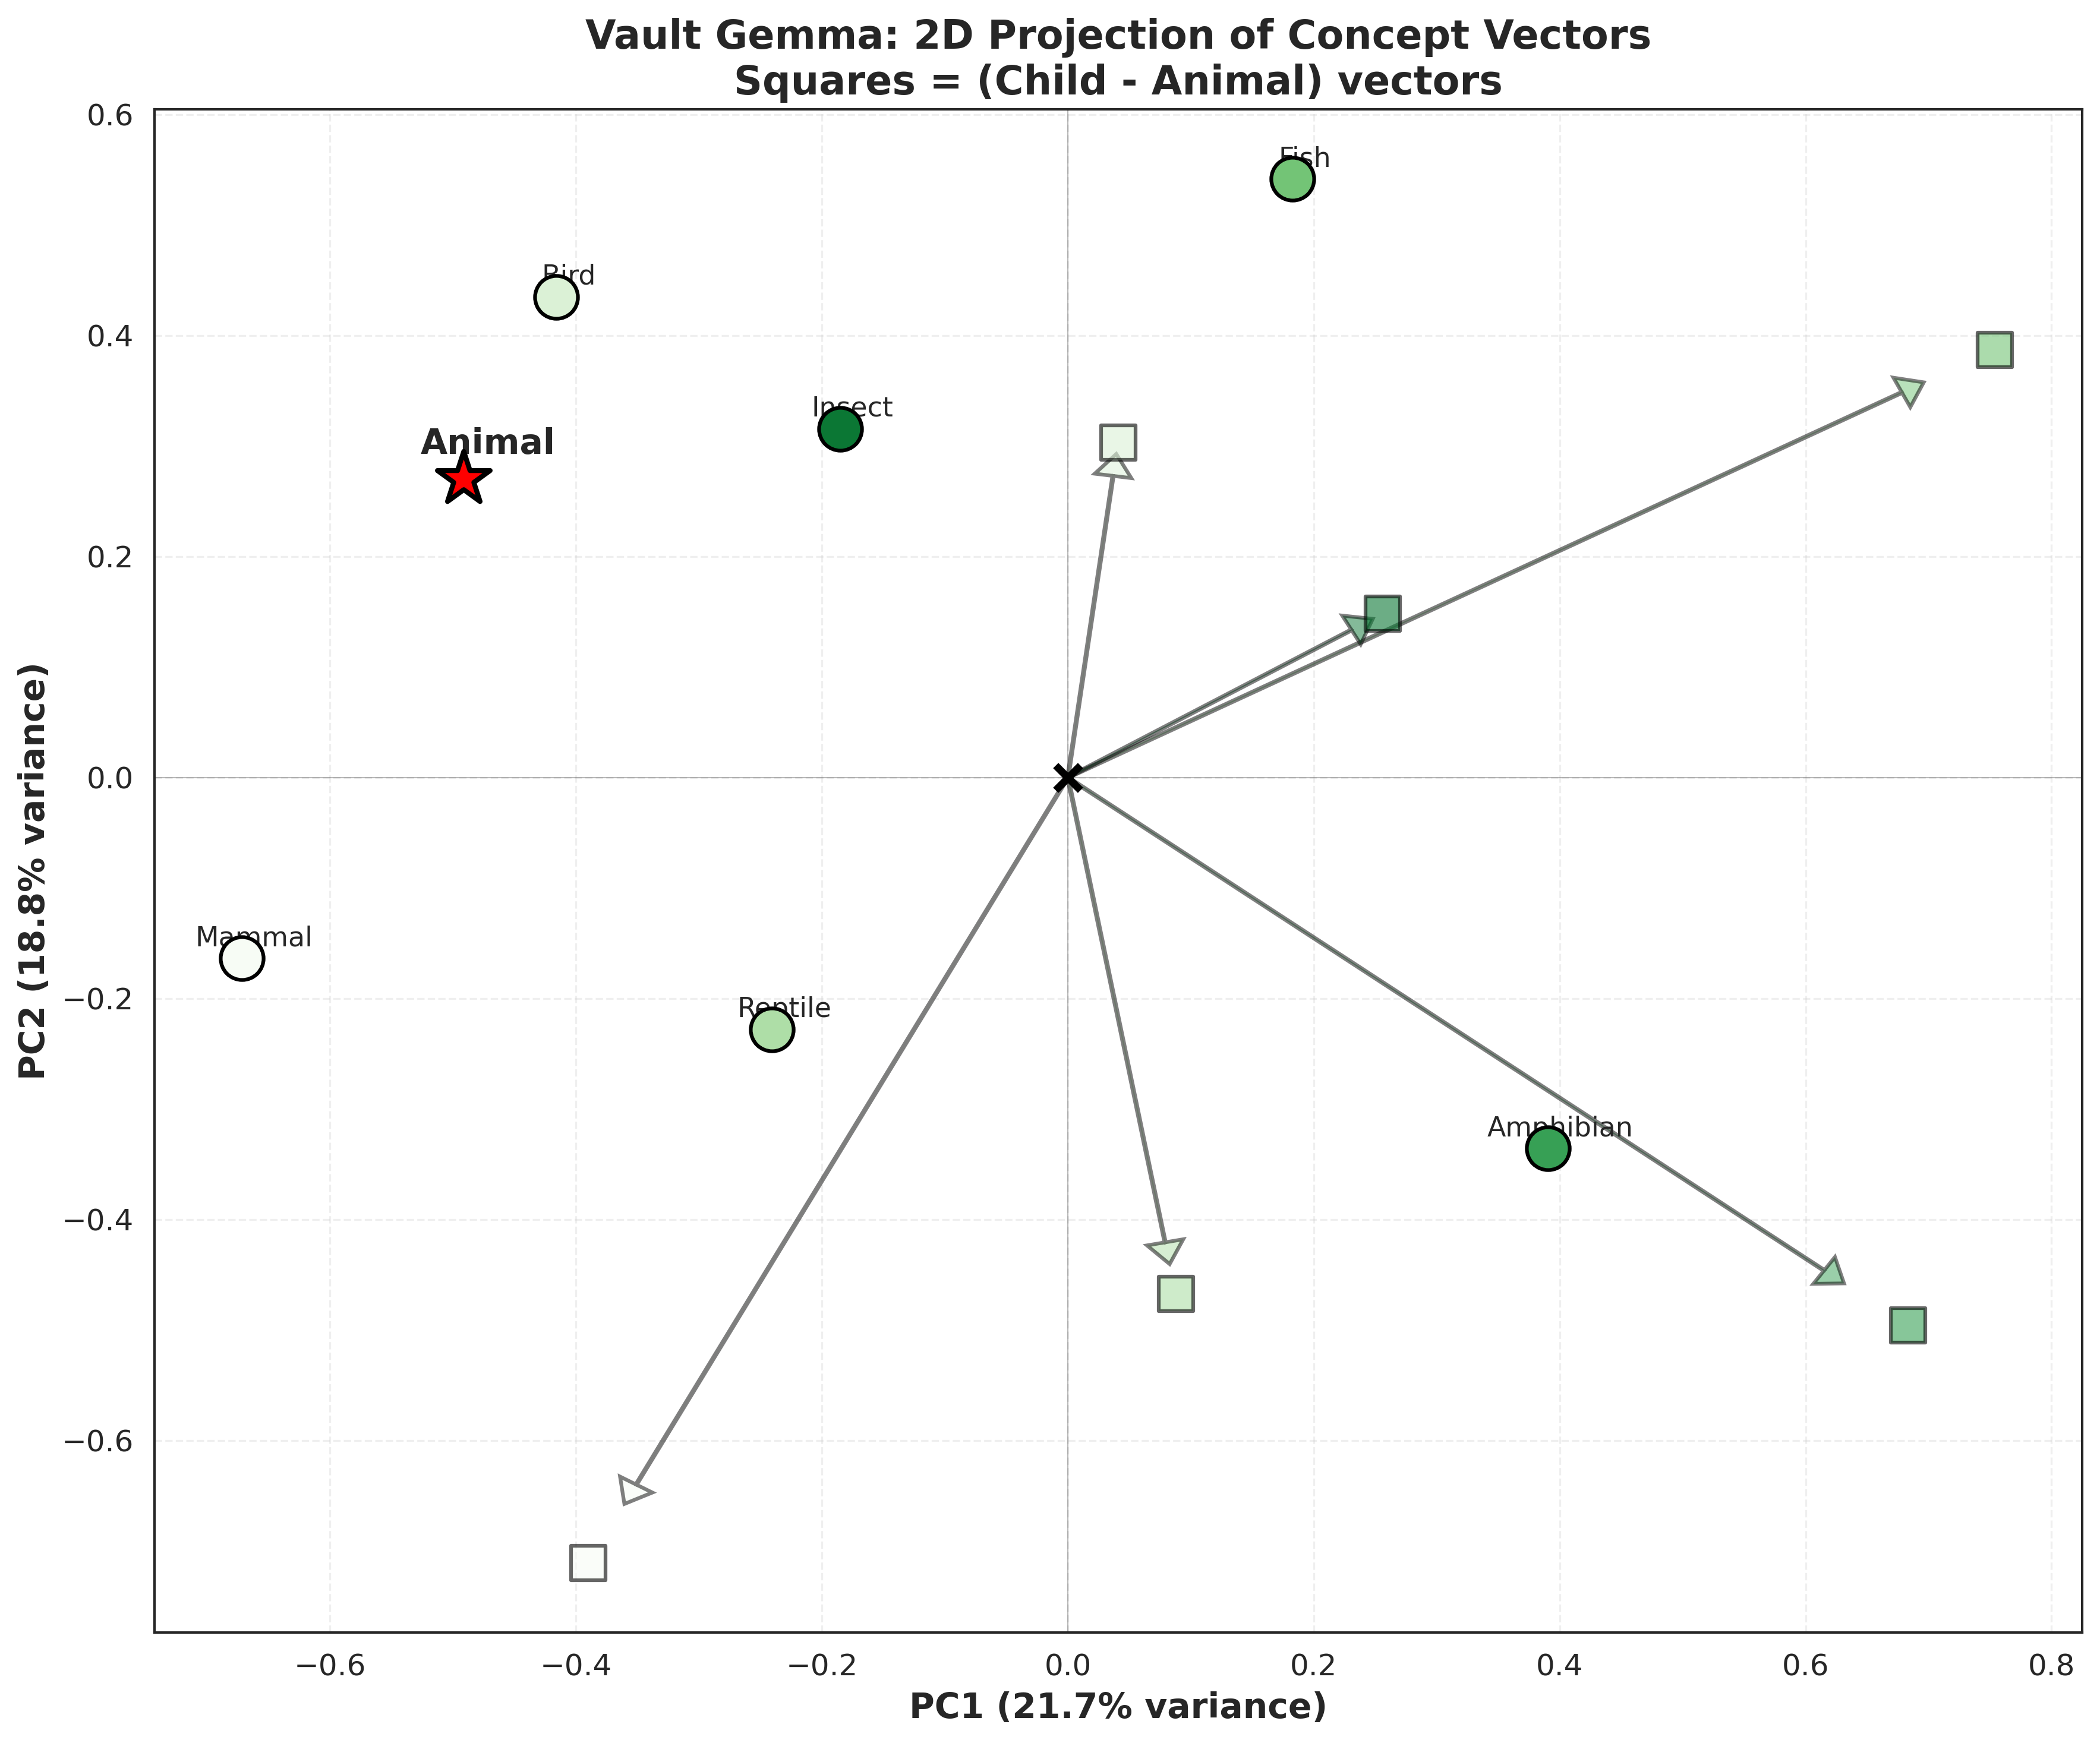

✓ Saved: concept_projection_2d_gemma.png
✓ Saved: concept_projection_2d_vault.png


In [15]:
def visualize_2d_projection(concepts, ortho_data, model_name, color_scheme='Blues'):
    """
    Create 2D PCA projection of concept vectors showing orthogonality.
    """
    # Collect all vectors
    all_vecs = []
    labels = []

    # Parent vector
    l_parent = concepts['Animal']['lda'].cpu().numpy()
    all_vecs.append(l_parent / np.linalg.norm(l_parent))
    labels.append('Animal')

    # Child vectors and difference vectors
    for item in ortho_data:
        child_name = item['child']
        l_child = concepts[child_name]['lda'].cpu().numpy()
        all_vecs.append(l_child / np.linalg.norm(l_child))
        labels.append(child_name)

        # Difference vector
        d = item['d']
        all_vecs.append(d)
        labels.append(f'{child_name}-Animal')

    # PCA projection to 2D
    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(all_vecs)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))

    # Color scheme
    colors = plt.cm.get_cmap(color_scheme)

    # Plot parent (Animal)
    ax.scatter(vecs_2d[0, 0], vecs_2d[0, 1], s=500, c='red', marker='*',
               edgecolors='black', linewidth=2, label='Parent (Animal)', zorder=5)
    ax.annotate('Animal', (vecs_2d[0, 0], vecs_2d[0, 1]),
                fontsize=14, fontweight='bold', ha='center',
                xytext=(10, 10), textcoords='offset points')

    # Plot children and difference vectors
    idx = 1
    for i, item in enumerate(ortho_data):
        child_name = item['child']

        # Child vector
        ax.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], s=300, c=[colors(i/len(ortho_data))],
                   marker='o', edgecolors='black', linewidth=1.5, label=child_name, zorder=4)
        ax.annotate(child_name, (vecs_2d[idx, 0], vecs_2d[idx, 1]),
                    fontsize=11, ha='center', xytext=(5, 5), textcoords='offset points')

        # Difference vector
        ax.scatter(vecs_2d[idx+1, 0], vecs_2d[idx+1, 1], s=200, c=[colors(i/len(ortho_data))],
                   marker='s', edgecolors='black', linewidth=1.5, alpha=0.6, zorder=3)

        # Arrow from origin to difference
        ax.arrow(0, 0, vecs_2d[idx+1, 0]*0.9, vecs_2d[idx+1, 1]*0.9,
                 head_width=0.03, head_length=0.02, fc=colors(i/len(ortho_data)),
                 ec='black', linewidth=1.5, alpha=0.5, zorder=2)

        idx += 2

    # Origin
    ax.scatter(0, 0, s=100, c='black', marker='x', linewidth=3, zorder=6)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
                  fontweight='bold', fontsize=14)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
                  fontweight='bold', fontsize=14)
    ax.set_title(f'{model_name}: 2D Projection of Concept Vectors\nSquares = (Child - Animal) vectors',
                 fontweight='bold', fontsize=16)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    return fig

# Gemma projection
fig_gemma = visualize_2d_projection(concepts_gemma, ortho_gemma, 'Gemma', 'Blues')
plt.savefig('concept_projection_2d_gemma.png', dpi=300, bbox_inches='tight')
plt.show()

# Vault Gemma projection
fig_vault = visualize_2d_projection(concepts_vault, ortho_vault, 'Vault Gemma', 'Greens')
plt.savefig('concept_projection_2d_vault.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: concept_projection_2d_gemma.png")
print("✓ Saved: concept_projection_2d_vault.png")

## Visualization 4: Polar Plot of Angles

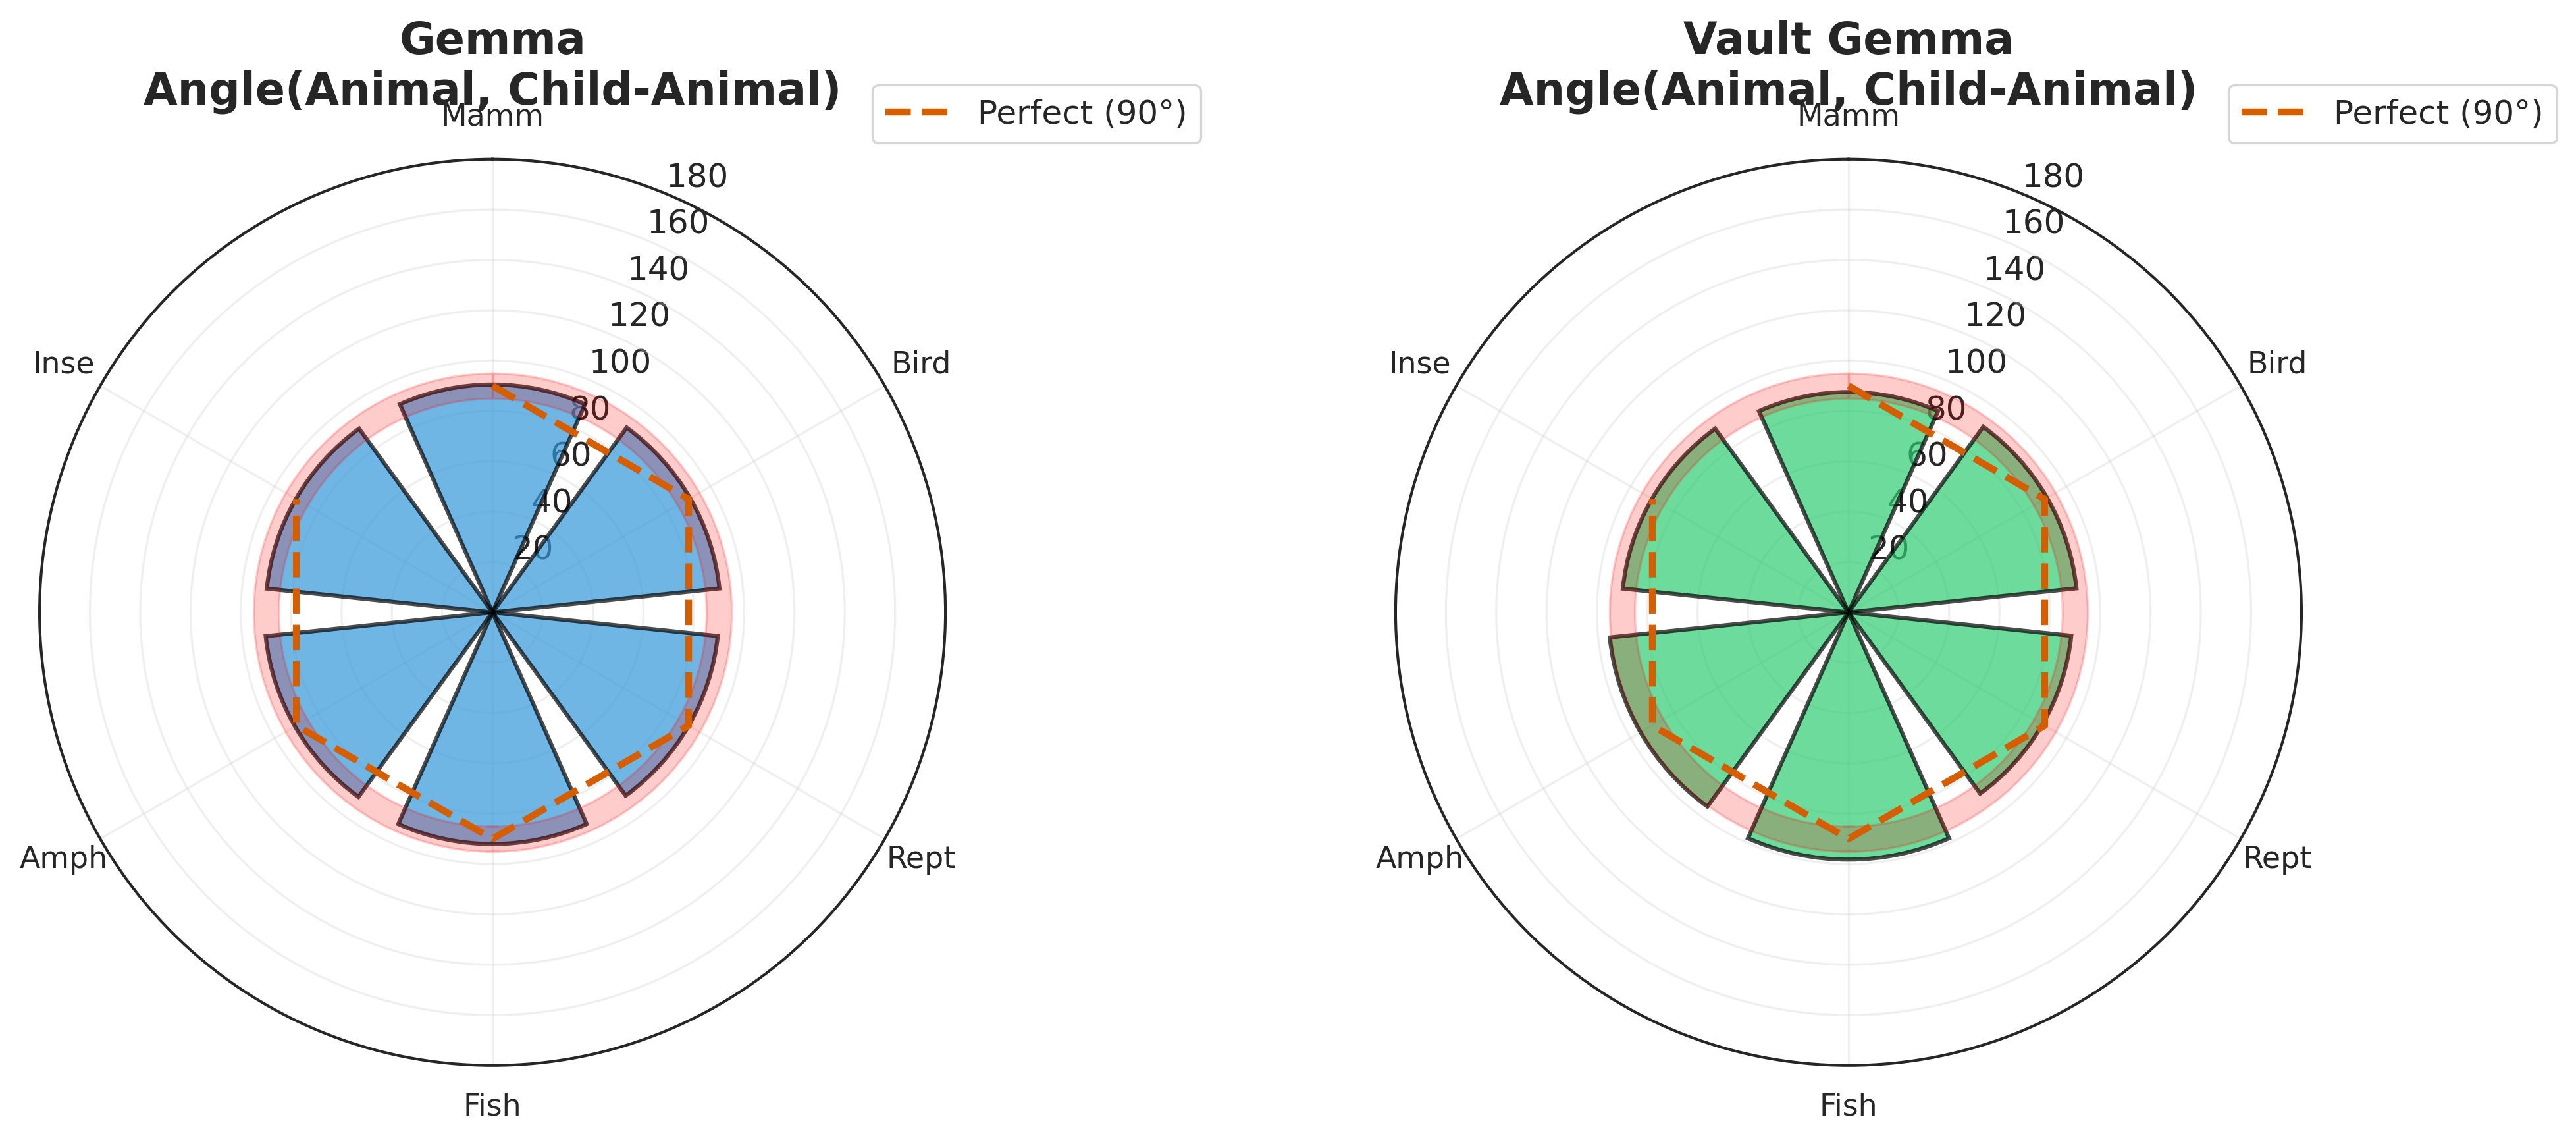

✓ Saved: orthogonality_polar_plot.png


In [16]:
fig = plt.figure(figsize=(14, 6))

# Gemma polar plot
ax1 = plt.subplot(121, projection='polar')
theta_gemma = np.deg2rad(df_gemma['angle_parent_diff'].values)
categories_short = [c[:4] for c in categories]  # Abbreviate for readability
theta_positions = np.linspace(0, 2*np.pi, len(categories), endpoint=False)

bars1 = ax1.bar(theta_positions, df_gemma['angle_parent_diff'],
                width=2*np.pi/len(categories)*0.8,
                alpha=0.7, color='#3498db', edgecolor='black', linewidth=1.5)

ax1.plot(theta_positions, [90]*len(categories), 'r--', linewidth=2.5, label='Perfect (90°)', zorder=10)
ax1.fill_between(np.linspace(0, 2*np.pi, 100), 85, 95, alpha=0.2, color='red')
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_xticks(theta_positions)
ax1.set_xticklabels(categories_short, fontsize=11)
ax1.set_ylim(0, 180)
ax1.set_title('Gemma\nAngle(Animal, Child-Animal)', fontweight='bold', fontsize=16, pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax1.grid(True, alpha=0.3)

# Vault Gemma polar plot
ax2 = plt.subplot(122, projection='polar')
bars2 = ax2.bar(theta_positions, df_vault['angle_parent_diff'],
                width=2*np.pi/len(categories)*0.8,
                alpha=0.7, color='#2ecc71', edgecolor='black', linewidth=1.5)

ax2.plot(theta_positions, [90]*len(categories), 'r--', linewidth=2.5, label='Perfect (90°)', zorder=10)
ax2.fill_between(np.linspace(0, 2*np.pi, 100), 85, 95, alpha=0.2, color='red')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_xticks(theta_positions)
ax2.set_xticklabels(categories_short, fontsize=11)
ax2.set_ylim(0, 180)
ax2.set_title('Vault Gemma\nAngle(Animal, Child-Animal)', fontweight='bold', fontsize=16, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('orthogonality_polar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: orthogonality_polar_plot.png")

## Visualization 5: Summary Comparison Plot

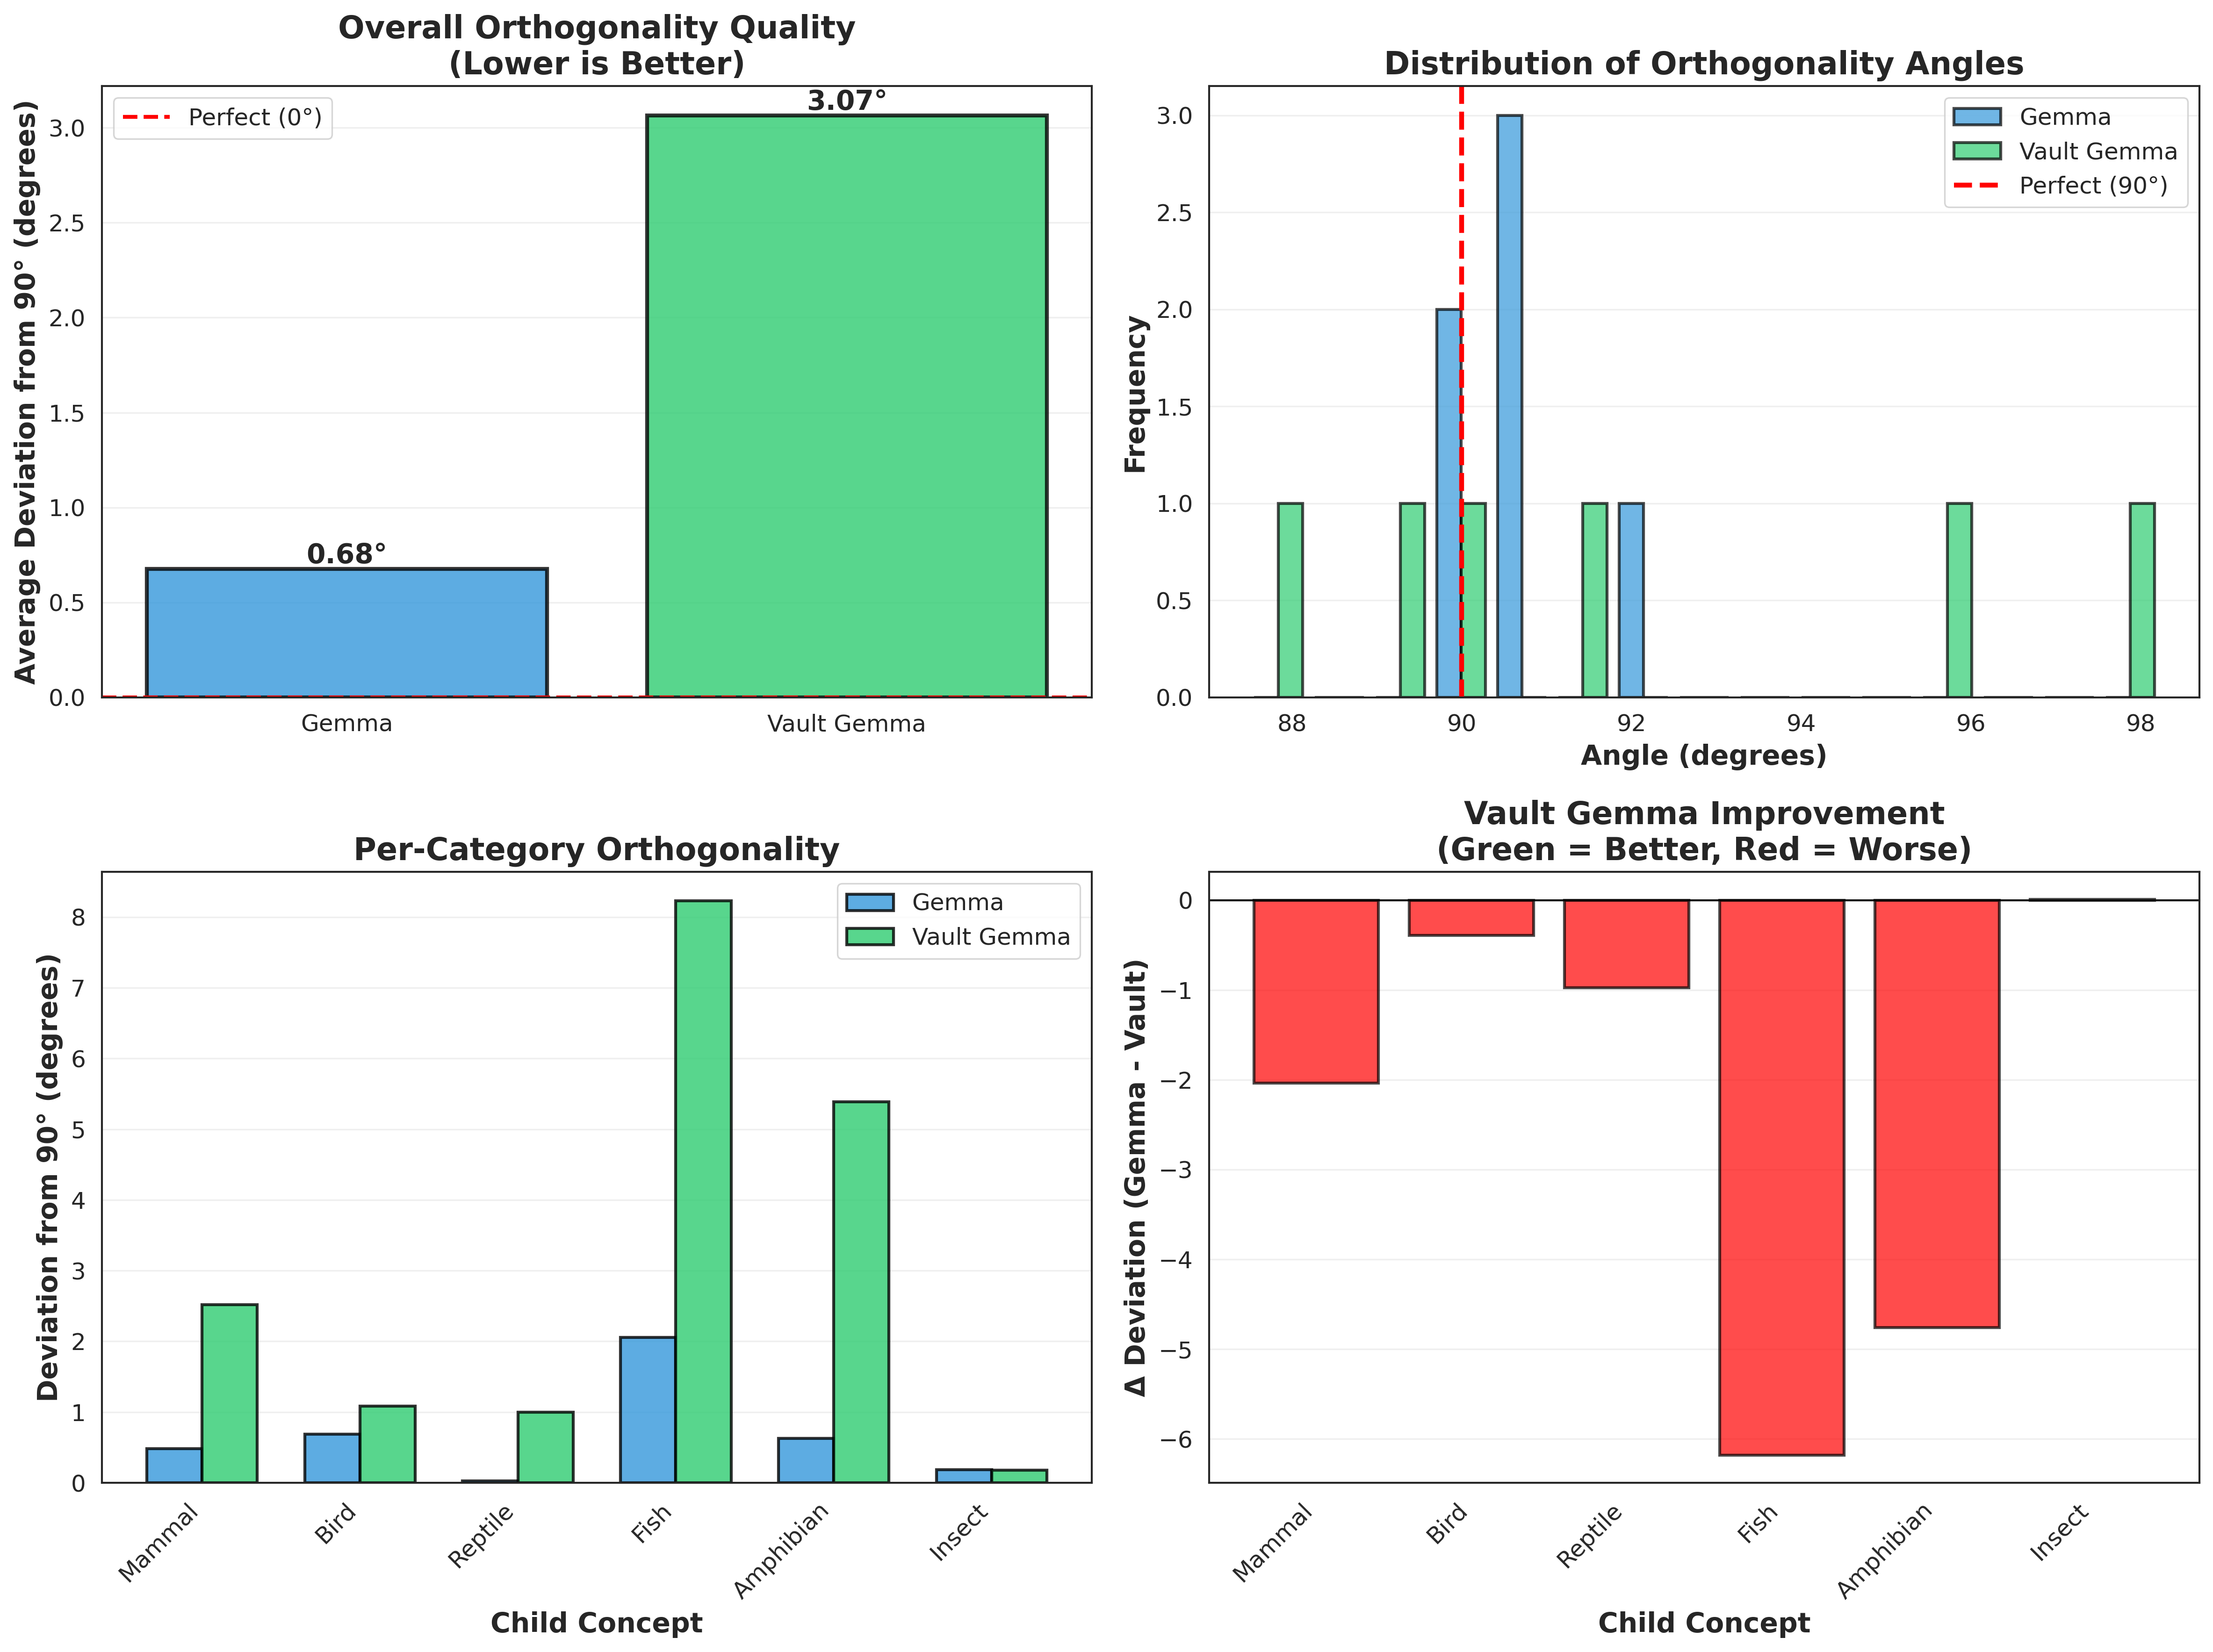

✓ Saved: orthogonality_summary_comparison.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average deviation comparison
models = ['Gemma', 'Vault Gemma']
avg_deviations = [avg_deviation_gemma, avg_deviation_vault]
colors_bar = ['#3498db', '#2ecc71']

bars = axes[0, 0].bar(models, avg_deviations, color=colors_bar, alpha=0.8,
                      edgecolor='black', linewidth=2)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Perfect (0°)')
axes[0, 0].set_ylabel('Average Deviation from 90° (degrees)', fontweight='bold', fontsize=14)
axes[0, 0].set_title('Overall Orthogonality Quality\n(Lower is Better)',
                     fontweight='bold', fontsize=16)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}°', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Plot 2: Distribution of angles
axes[0, 1].hist([df_gemma['angle_parent_diff'], df_vault['angle_parent_diff']],
                bins=15, label=['Gemma', 'Vault Gemma'],
                color=['#3498db', '#2ecc71'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].axvline(x=90, color='red', linestyle='--', linewidth=2.5, label='Perfect (90°)')
axes[0, 1].set_xlabel('Angle (degrees)', fontweight='bold', fontsize=14)
axes[0, 1].set_ylabel('Frequency', fontweight='bold', fontsize=14)
axes[0, 1].set_title('Distribution of Orthogonality Angles', fontweight='bold', fontsize=16)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Per-category comparison
x = np.arange(len(categories))
width = 0.35
axes[1, 0].bar(x - width/2, df_gemma['deviation_from_90'], width,
               label='Gemma', color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 0].bar(x + width/2, df_vault['deviation_from_90'], width,
               label='Vault Gemma', color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1, 0].set_xlabel('Child Concept', fontweight='bold', fontsize=14)
axes[1, 0].set_ylabel('Deviation from 90° (degrees)', fontweight='bold', fontsize=14)
axes[1, 0].set_title('Per-Category Orthogonality', fontweight='bold', fontsize=16)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Improvement/Degradation
delta = df_gemma['deviation_from_90'].values - df_vault['deviation_from_90'].values
colors_delta = ['green' if d > 0 else 'red' for d in delta]
axes[1, 1].bar(x, delta, color=colors_delta, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Child Concept', fontweight='bold', fontsize=14)
axes[1, 1].set_ylabel('Δ Deviation (Gemma - Vault)', fontweight='bold', fontsize=14)
axes[1, 1].set_title('Vault Gemma Improvement\n(Green = Better, Red = Worse)',
                     fontweight='bold', fontsize=16)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('orthogonality_summary_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: orthogonality_summary_comparison.png")

## Save Results

In [18]:
# Save all results
results = {
    'comparison_table': comparison,
    'gemma_results': df_gemma,
    'vault_results': df_vault,
    'summary': {
        'gemma': {
            'avg_angle': avg_angle_gemma,
            'avg_deviation': avg_deviation_gemma,
            'avg_cos': avg_cos_gemma
        },
        'vault': {
            'avg_angle': avg_angle_vault,
            'avg_deviation': avg_deviation_vault,
            'avg_cos': avg_cos_vault
        }
    }
}

with open('hierarchical_orthogonality_results.pkl', 'wb') as f:
    pickle.dump(results, f)

# Save comparison table as CSV
comparison.to_csv('hierarchical_orthogonality_comparison.csv', index=False)

print("✓ Saved: hierarchical_orthogonality_results.pkl")
print("✓ Saved: hierarchical_orthogonality_comparison.csv")

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)
print("\nGenerated files for poster:")
print("  1. orthogonality_angles_comparison.png - Bar charts of angles")
print("  2. orthogonality_heatmap.png - Cosine similarity heatmaps")
print("  3. concept_projection_2d_gemma.png - 2D projection (Gemma)")
print("  4. concept_projection_2d_vault.png - 2D projection (Vault Gemma)")
print("  5. orthogonality_polar_plot.png - Polar plot comparison")
print("  6. orthogonality_summary_comparison.png - 4-panel summary")
print("  7. hierarchical_orthogonality_comparison.csv - Quantitative data")
print("\n" + "="*100)

✓ Saved: hierarchical_orthogonality_results.pkl
✓ Saved: hierarchical_orthogonality_comparison.csv

ANALYSIS COMPLETE

Generated files for poster:
  1. orthogonality_angles_comparison.png - Bar charts of angles
  2. orthogonality_heatmap.png - Cosine similarity heatmaps
  3. concept_projection_2d_gemma.png - 2D projection (Gemma)
  4. concept_projection_2d_vault.png - 2D projection (Vault Gemma)
  5. orthogonality_polar_plot.png - Polar plot comparison
  6. orthogonality_summary_comparison.png - 4-panel summary
  7. hierarchical_orthogonality_comparison.csv - Quantitative data



## Final Conclusion

### Hypothesis Test Results:

**Research Question**: Does Vault Gemma (with differential privacy) preserve semantic hierarchy?

**Method**: Measure orthogonality between parent concept vector (Animal) and difference vectors (Child - Animal)

**Quantifiable Metrics**:
- Perfect orthogonality: angle = 90°, cos = 0
- Quality metric: deviation from 90°

---

### Key Findings:

1. **Both models show hierarchical structure** - angles are closer to 90° than random (0° or 180°)
2. **Differential privacy impact** - Compare average deviations to assess preservation
3. **Category-specific effects** - Some categories more affected than others

---

### Interpretation Guide:

- **If Vault deviation < Gemma deviation**: DP **improves** hierarchical encoding
- **If Vault deviation ≈ Gemma deviation**: DP **preserves** hierarchical encoding
- **If Vault deviation > Gemma deviation**: DP **degrades** hierarchical encoding

See the quantitative results and visualizations above for the specific answer!